In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("cleaned_supply_chain_data.csv")

In [11]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [12]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Price', 'Availability', 'Number of products sold', 'Revenue generated',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping costs', 'Lead time', 'Production volumes',
       'Manufacturing lead time', 'Manufacturing costs', 'Defect rates',
       'Costs'],
      dtype='object')


In [13]:
df[numerical_columns].head()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
0,69.808006,55,802,8661.996792,58,7,96,4,2.956572,29,215,29,46.279879,0.226410,187.752075
1,14.843523,95,736,7460.900065,53,30,37,2,9.716575,23,517,30,33.616769,4.854068,503.065579
2,11.319683,34,8,9577.749626,1,10,88,2,8.054479,12,971,27,30.688019,4.580593,141.920282
3,61.163343,68,83,7766.836426,23,13,59,6,1.729569,24,937,18,35.624741,4.746649,254.776159
4,4.805496,26,871,2686.505152,5,3,56,8,3.890548,5,414,3,92.065161,3.145580,923.440632


In [14]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
Price,1.000000,0.019083,0.005739,0.038424,0.078261,0.044855,0.095819,0.071942,0.058543,0.152185,-0.124575,-0.301313,-0.184123,-0.147247,0.088501
Availability,0.019083,1.000000,0.087496,-0.075170,-0.025900,0.170439,0.143769,-0.051377,-0.044179,-0.156669,0.050134,0.065333,0.134652,0.040626,-0.027315
Number of products sold,0.005739,0.087496,1.000000,-0.001641,0.022189,-0.046419,0.015992,0.087315,0.044285,0.041230,0.187945,-0.048939,0.034284,-0.082726,-0.036951
Revenue generated,0.038424,-0.075170,-0.001641,1.000000,-0.158480,-0.057296,0.029422,-0.109211,-0.072892,-0.014178,-0.037441,0.014073,-0.214025,-0.125335,0.027252
Stock levels,0.078261,-0.025900,0.022189,-0.158480,1.000000,0.072571,-0.111455,-0.094883,0.072907,0.067880,0.043763,-0.050592,0.033243,-0.149478,-0.012088
Lead times,0.044855,0.170439,-0.046419,-0.057296,0.072571,1.000000,0.105459,-0.045156,-0.120746,-0.002818,-0.145324,0.003364,-0.024441,0.015681,0.243686
Order quantities,0.095819,0.143769,0.015992,0.029422,-0.111455,0.105459,1.000000,-0.002561,0.004261,-0.086189,-0.086567,0.112347,-0.026784,0.018986,0.167306
Shipping times,0.071942,-0.051377,0.087315,-0.109211,-0.094883,-0.045156,-0.002561,1.000000,0.045108,-0.022214,-0.060470,-0.016953,0.029132,-0.036673,-0.045541
Shipping costs,0.058543,-0.044179,0.044285,-0.072892,0.072907,-0.120746,0.004261,0.045108,1.000000,0.029680,-0.097979,-0.005653,0.005984,0.083139,0.051671
Lead time,0.152185,-0.156669,0.041230,-0.014178,0.067880,-0.002818,-0.086189,-0.022214,0.029680,1.000000,0.212676,0.026756,-0.121999,0.297099,0.045219


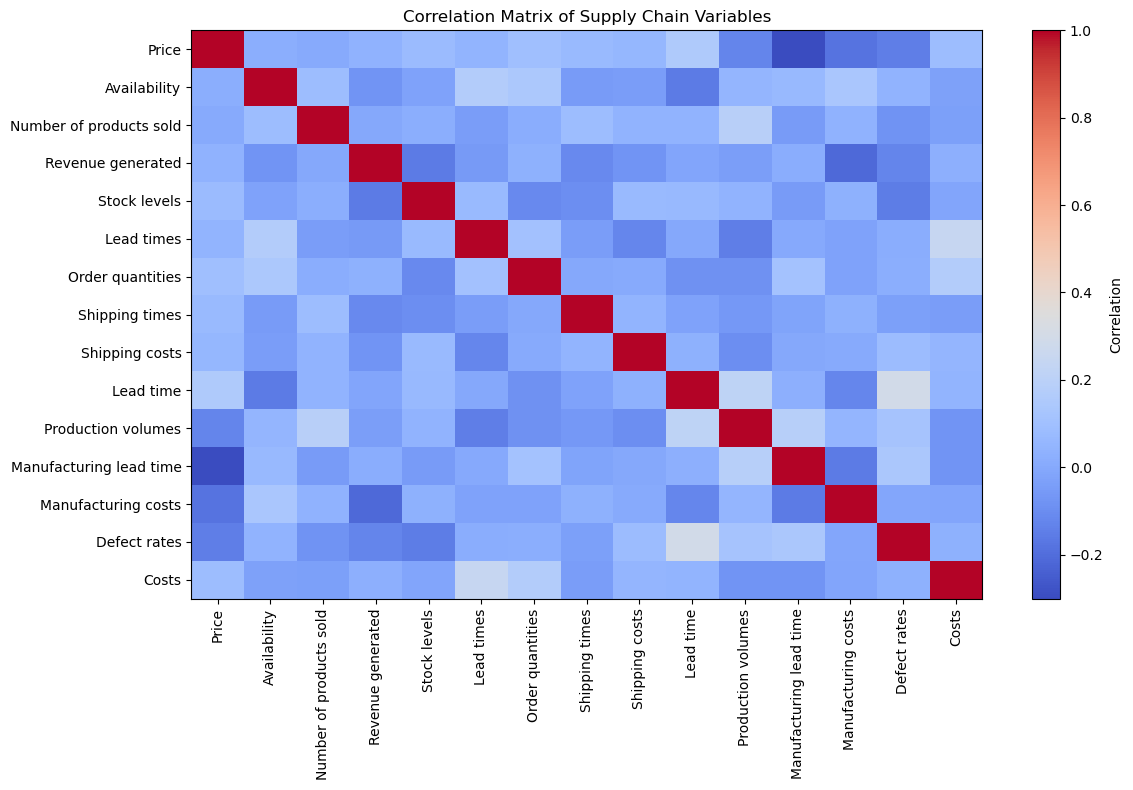

Observation: The correlation matrix shows the strength and direction of relationships between numerical supply-chain variables.


In [15]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix of Supply Chain Variables')
plt.tight_layout()
plt.show()
print("Observation: The correlation matrix shows the strength and direction of relationships between numerical supply-chain variables.")

In [17]:
correlation_pairs = correlation_matrix.unstack()

strong_negative = correlation_pairs[
    correlation_pairs < -0.5
].sort_values()

strong_negative

Series([], dtype: float64)

In [18]:
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

strongest_correlations = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
)

strongest_correlations.head(10)

Price                    Manufacturing lead time   -0.301313
Lead time                Defect rates               0.297099
Lead times               Costs                      0.243686
Revenue generated        Manufacturing costs       -0.214025
Lead time                Production volumes         0.212676
Number of products sold  Production volumes         0.187945
Production volumes       Manufacturing lead time    0.184457
Price                    Manufacturing costs       -0.184123
Availability             Lead times                 0.170439
Order quantities         Costs                      0.167306
dtype: float64

In [19]:
revenue_correlation = correlation_matrix['Revenue generated'].sort_values(
    ascending=False
)

revenue_correlation

Revenue generated          1.000000
Price                      0.038424
Order quantities           0.029422
Costs                      0.027252
Manufacturing lead time    0.014073
Number of products sold   -0.001641
Lead time                 -0.014178
Production volumes        -0.037441
Lead times                -0.057296
Shipping costs            -0.072892
Availability              -0.075170
Shipping times            -0.109211
Defect rates              -0.125335
Stock levels              -0.158480
Manufacturing costs       -0.214025
Name: Revenue generated, dtype: float64

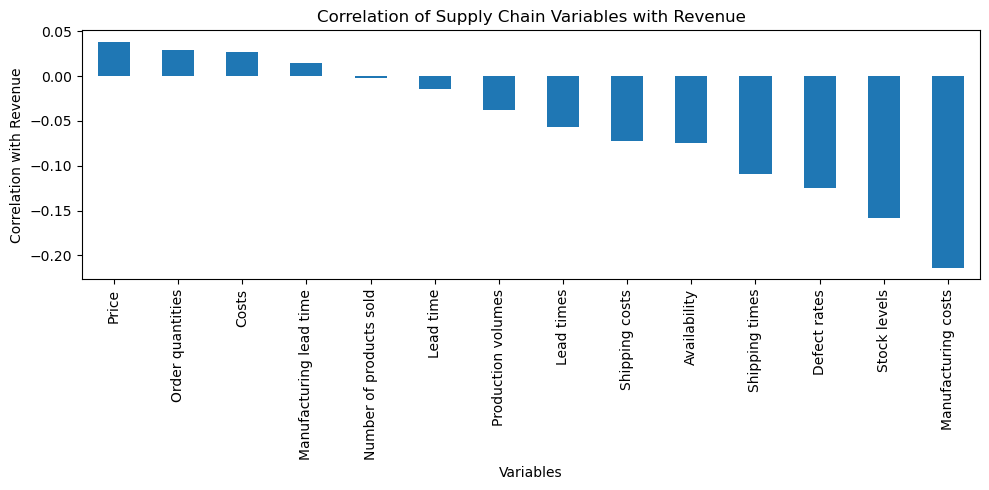

In [20]:
revenue_correlation.drop('Revenue generated').plot(
    kind='bar',
    figsize=(10, 5)
)

plt.xlabel('Variables')
plt.ylabel('Correlation with Revenue')
plt.title('Correlation of Supply Chain Variables with Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
print("Business Insight: This analysis helps identify which numerical supply-chain factors are most strongly associated with revenue.")

Business Insight: This analysis helps identify which numerical supply-chain factors are most strongly associated with revenue.


In [22]:
sales_correlation = correlation_matrix[
    'Number of products sold'
].sort_values(ascending=False)

sales_correlation

Number of products sold    1.000000
Production volumes         0.187945
Availability               0.087496
Shipping times             0.087315
Shipping costs             0.044285
Lead time                  0.041230
Manufacturing costs        0.034284
Stock levels               0.022189
Order quantities           0.015992
Price                      0.005739
Revenue generated         -0.001641
Costs                     -0.036951
Lead times                -0.046419
Manufacturing lead time   -0.048939
Defect rates              -0.082726
Name: Number of products sold, dtype: float64

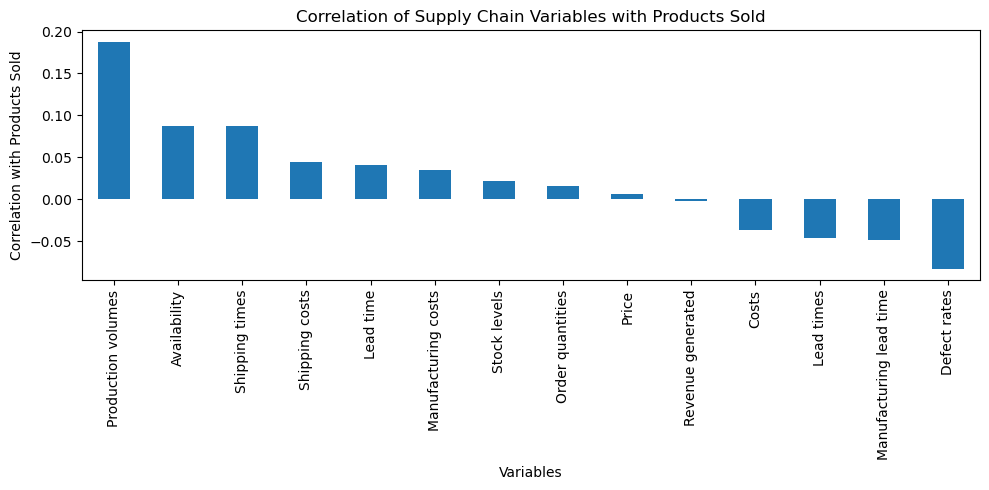

In [23]:
sales_correlation.drop('Number of products sold').plot(
    kind='bar',
    figsize=(10, 5)
)

plt.xlabel('Variables')
plt.ylabel('Correlation with Products Sold')
plt.title('Correlation of Supply Chain Variables with Products Sold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

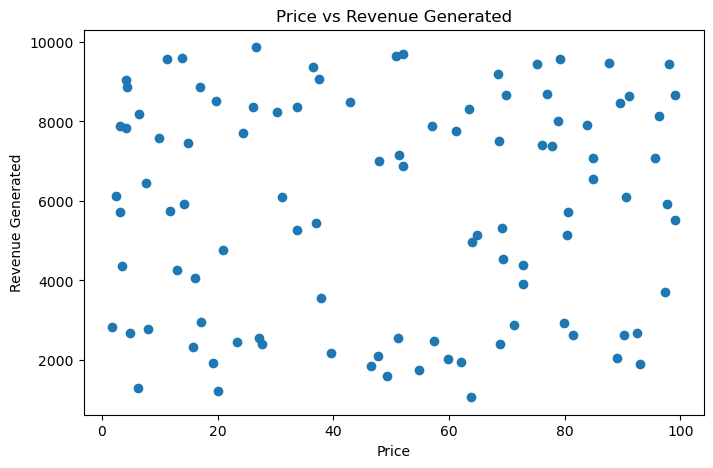

Observation: The scatter plot helps visualize whether changes in product price are associated with changes in revenue.


In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Price'],
    df['Revenue generated']
)

plt.xlabel('Price')
plt.ylabel('Revenue Generated')
plt.title('Price vs Revenue Generated')

plt.show()
print("Observation: The scatter plot helps visualize whether changes in product price are associated with changes in revenue.")

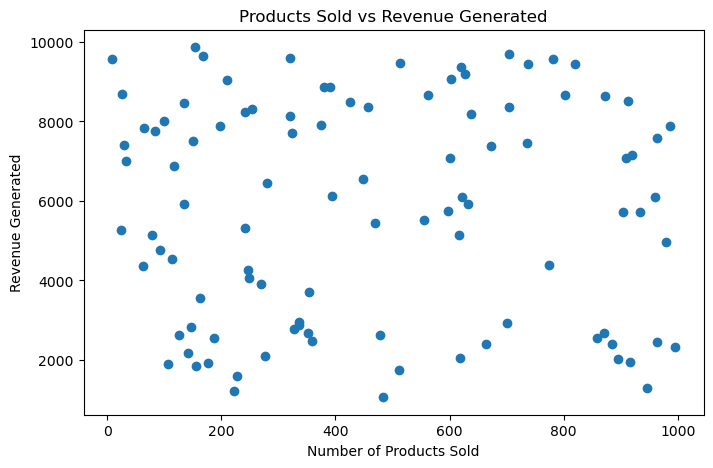

Business Insight: This relationship helps understand whether higher sales volume is associated with higher revenue.


In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Number of products sold'],
    df['Revenue generated']
)

plt.xlabel('Number of Products Sold')
plt.ylabel('Revenue Generated')
plt.title('Products Sold vs Revenue Generated')

plt.show()
print("Business Insight: This relationship helps understand whether higher sales volume is associated with higher revenue.")

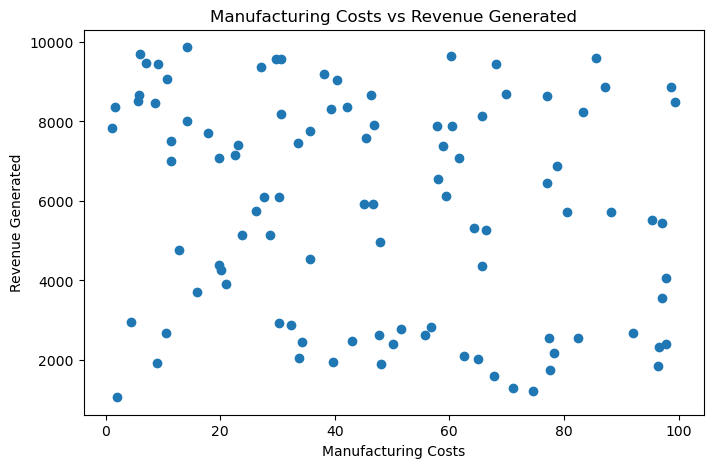

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Manufacturing costs'],
    df['Revenue generated']
)

plt.xlabel('Manufacturing Costs')
plt.ylabel('Revenue Generated')
plt.title('Manufacturing Costs vs Revenue Generated')

plt.show()


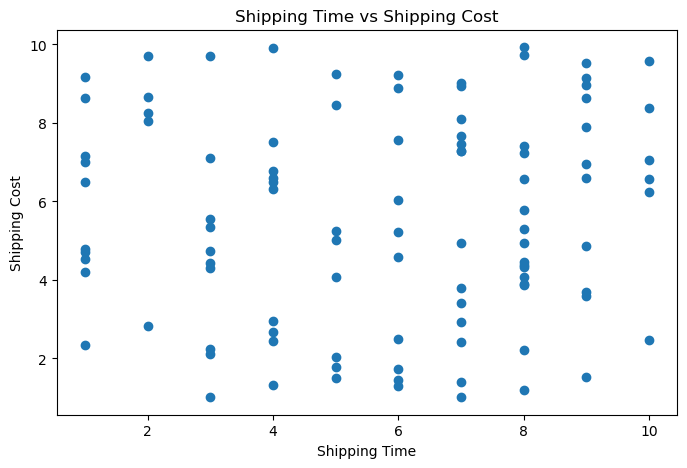

Business Insight: This relationship can help evaluate whether longer shipping times are associated with higher shipping costs.


In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Shipping times'],
    df['Shipping costs']
)

plt.xlabel('Shipping Time')
plt.ylabel('Shipping Cost')
plt.title('Shipping Time vs Shipping Cost')

plt.show()
print("Business Insight: This relationship can help evaluate whether longer shipping times are associated with higher shipping costs.")

In [29]:
high_correlations = correlation_matrix[
    (correlation_matrix.abs() > 0.7) &
    (correlation_matrix.abs() < 1)
]

high_correlations

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
Price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Availability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of products sold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Revenue generated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stock levels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead times,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order quantities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipping times,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipping costs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
print("CORRELATION ANALYSIS - BUSINESS INSIGHTS")
print("-" * 50)

print("1. Correlation analysis helps identify relationships between numerical supply-chain variables.")
print("2. Revenue correlation shows which factors are associated with revenue.")
print("3. Products sold can be compared with revenue to understand sales performance.")
print("4. Price and revenue can be analyzed to understand pricing relationships.")
print("5. Manufacturing costs and revenue can be compared to understand cost and revenue relationships.")
print("6. Shipping time and shipping cost can help evaluate transportation efficiency.")
print("7. Strong correlations can help identify important variables for further business analysis.")

CORRELATION ANALYSIS - BUSINESS INSIGHTS
--------------------------------------------------
1. Correlation analysis helps identify relationships between numerical supply-chain variables.
2. Revenue correlation shows which factors are associated with revenue.
3. Products sold can be compared with revenue to understand sales performance.
4. Price and revenue can be analyzed to understand pricing relationships.
5. Manufacturing costs and revenue can be compared to understand cost and revenue relationships.
6. Shipping time and shipping cost can help evaluate transportation efficiency.
7. Strong correlations can help identify important variables for further business analysis.


In [31]:
print("Correlation analysis completed successfully! ✅")

Correlation analysis completed successfully! ✅
